<a href="https://colab.research.google.com/github/Foll0wTh3Wh1teRabbit/ML/blob/master/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Метод k-средних (англ. k-means) — наиболее популярный метод кластеризации. Был изобретён в 1950-х годах математиком Гуго Штейнгаузом и почти одновременно Стюартом Ллойдом. Особую популярность приобрёл после работы Маккуина.

Действие алгоритма таково, что он стремится минимизировать суммарное квадратичное отклонение точек кластеров от центров этих кластеров.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import silhouette_score

In [ ]:
centers = [[1, 1], [-1, -1], [1, -1]]

X, y_true = make_blobs(n_samples=500, centers=centers, cluster_std=0.4, random_state=40000)

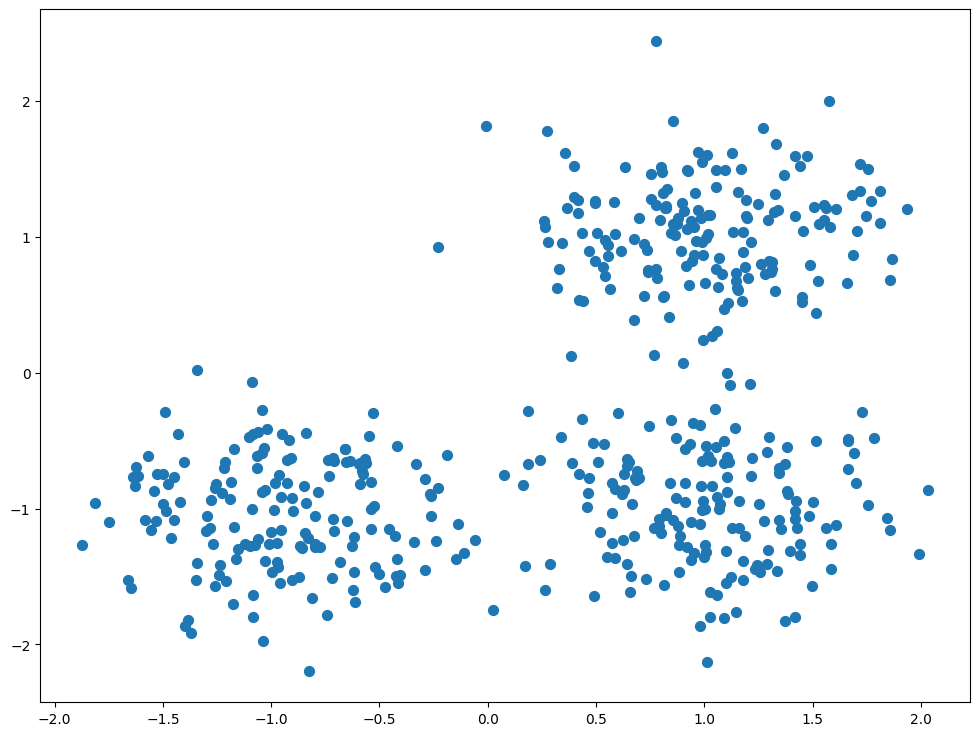

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.show()

Используем в лоб K-means для понимания картины

In [ ]:
predicted = KMeans(init='random').fit_predict(X)

predicted

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([1, 3, 7, 4, 5, 0, 4, 6, 6, 6, 5, 4, 1, 1, 1, 1, 1, 5, 6, 0, 2, 7,
       4, 1, 6, 5, 5, 5, 1, 6, 3, 5, 3, 6, 1, 6, 2, 6, 3, 3, 0, 7, 6, 4,
       5, 6, 5, 2, 0, 2, 5, 7, 7, 7, 5, 6, 0, 1, 6, 2, 4, 5, 7, 6, 3, 3,
       5, 6, 0, 4, 4, 6, 5, 1, 3, 7, 4, 7, 2, 6, 2, 2, 5, 5, 7, 5, 6, 7,
       6, 2, 1, 7, 2, 0, 5, 5, 3, 3, 0, 7, 5, 4, 0, 5, 5, 6, 2, 5, 4, 3,
       6, 7, 7, 6, 5, 5, 6, 7, 6, 0, 1, 0, 0, 3, 3, 1, 4, 0, 4, 1, 6, 6,
       3, 7, 3, 3, 2, 2, 1, 6, 0, 5, 1, 2, 2, 5, 6, 6, 1, 3, 7, 3, 3, 4,
       3, 2, 2, 3, 3, 6, 2, 5, 0, 0, 7, 1, 6, 5, 3, 1, 1, 6, 0, 7, 2, 1,
       6, 2, 1, 3, 3, 1, 5, 2, 0, 7, 6, 2, 2, 5, 1, 5, 0, 3, 1, 6, 0, 1,
       7, 2, 5, 6, 1, 2, 6, 1, 1, 5, 5, 5, 3, 1, 2, 3, 4, 7, 5, 6, 5, 1,
       5, 4, 0, 3, 5, 2, 0, 4, 3, 4, 7, 6, 0, 2, 3, 3, 4, 3, 5, 3, 0, 1,
       3, 6, 1, 0, 5, 5, 2, 6, 0, 6, 6, 0, 3, 0, 0, 4, 2, 1, 5, 6, 1, 6,
       4, 5, 0, 7, 7, 6, 1, 4, 7, 1, 0, 6, 3, 7, 2, 0, 6, 0, 5, 2, 3, 6,
       0, 5, 4, 4, 5, 3, 2, 4, 5, 6, 2, 2, 1, 1, 1,

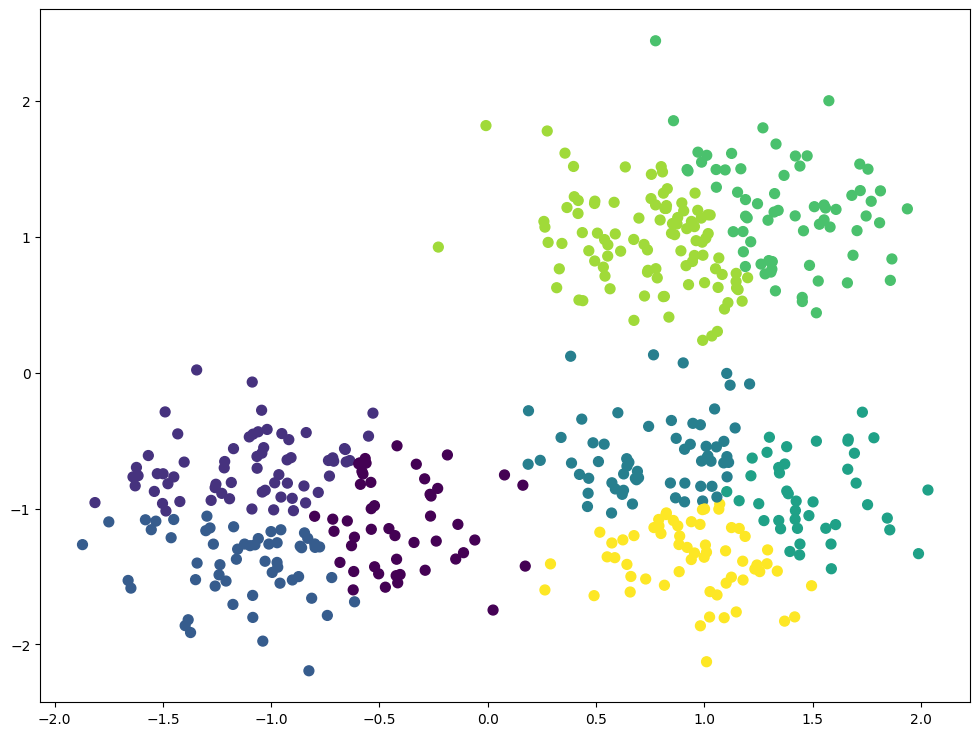

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], c=predicted, s=50)
plt.show()

Попробуем подобрать параметры.  
Используем Silhouette-score для определения числа кластеров.

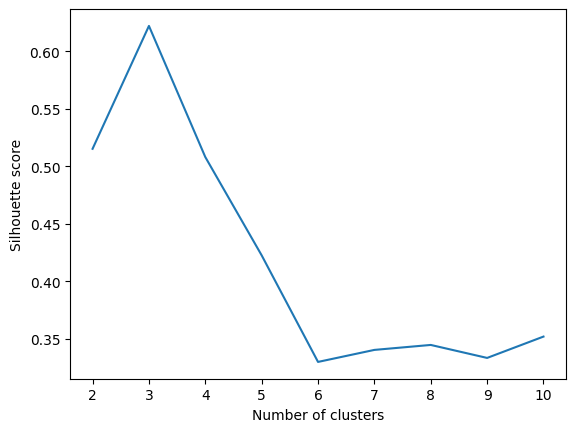

In [ ]:
scores = []
for K in range(2,11):
  clusterer = KMeans(init='random', n_clusters=K, n_init=10)
  model = clusterer.fit_predict(X)
  score = silhouette_score(X, model)
  scores.append(score)

Ks = [i for i in range(2,11)]

plt.plot(Ks, scores)

plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')

plt.show()

Получили наилучшее значение метрики для K=3.  
Используем его для алгоритма.

In [ ]:
predicted = KMeans(n_clusters=3, init='random').fit_predict(X)

predicted

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([2, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0,
       0, 2, 1, 1, 1, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 0, 2, 0, 1, 0,
       1, 1, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 2, 0, 1, 0, 1, 0, 0,
       1, 1, 2, 0, 0, 1, 1, 2, 0, 0, 0, 0, 2, 1, 2, 2, 1, 1, 0, 1, 1, 0,
       1, 2, 2, 0, 2, 2, 1, 1, 0, 0, 2, 0, 1, 0, 2, 1, 1, 1, 2, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 2, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 1, 1,
       0, 0, 0, 0, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 1, 2, 1, 2, 2, 0, 2, 1, 1, 0, 2, 2, 1, 2, 0, 2, 2,
       1, 2, 2, 0, 0, 2, 1, 2, 2, 0, 1, 2, 2, 1, 2, 1, 2, 0, 2, 1, 2, 2,
       0, 2, 1, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 1, 1, 1, 2,
       1, 0, 2, 0, 1, 2, 2, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 0, 1, 0, 2, 2,
       0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 0, 0, 2, 2, 0, 2, 2, 1, 1, 2, 1,
       0, 1, 0, 0, 0, 1, 2, 0, 0, 2, 2, 1, 0, 0, 2, 2, 1, 2, 1, 2, 0, 1,
       2, 1, 0, 0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 2, 2,

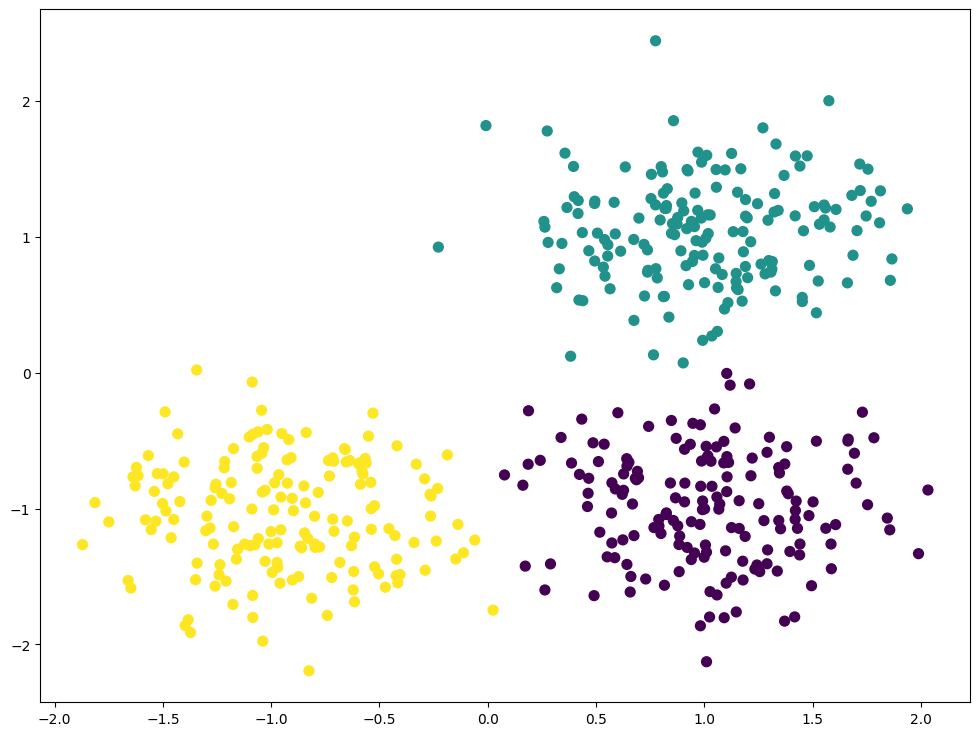

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], c=predicted, s=50)
plt.show()

Видим хорошую картину, попробуем K-means++

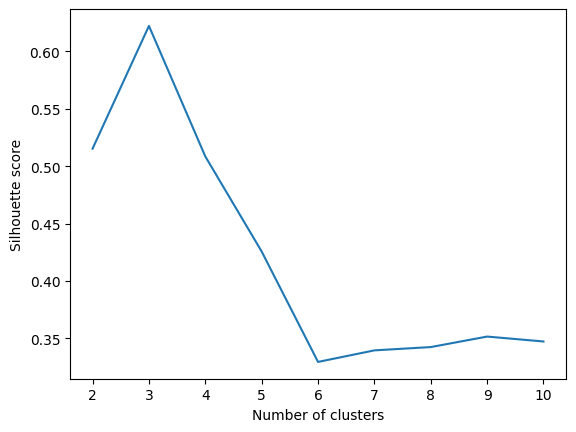

In [ ]:
scores = []
for K in range(2,11):
  clusterer = KMeans(init='k-means++', n_clusters=K, n_init=10)
  model = clusterer.fit_predict(X)
  score = silhouette_score(X, model)
  scores.append(score)

Ks = [i for i in range(2,11)]

plt.plot(Ks, scores)

plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')

plt.show()

In [ ]:
predicted = KMeans(n_clusters=3, init='k-means++').fit_predict(X)

predicted

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([2, 1, 1, 1, 0, 2, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 1,
       1, 2, 0, 0, 0, 0, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 1, 1, 2, 1, 0, 1,
       0, 0, 0, 2, 2, 2, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 1, 0, 1, 0, 1, 1,
       0, 0, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1, 2, 0, 2, 2, 0, 0, 1, 0, 0, 1,
       0, 2, 2, 1, 2, 2, 0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 0, 0, 2, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 0, 0,
       1, 1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 2, 2, 0, 2, 1, 2, 2,
       0, 2, 2, 1, 1, 2, 0, 2, 2, 1, 0, 2, 2, 0, 2, 0, 2, 1, 2, 0, 2, 2,
       1, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 0, 0, 0, 2,
       0, 1, 2, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 2, 2,
       1, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 0, 2, 0,
       1, 0, 1, 1, 1, 0, 2, 1, 1, 2, 2, 0, 1, 1, 2, 2, 0, 2, 0, 2, 1, 0,
       2, 0, 1, 1, 0, 1, 2, 1, 0, 0, 2, 2, 2, 2, 2,

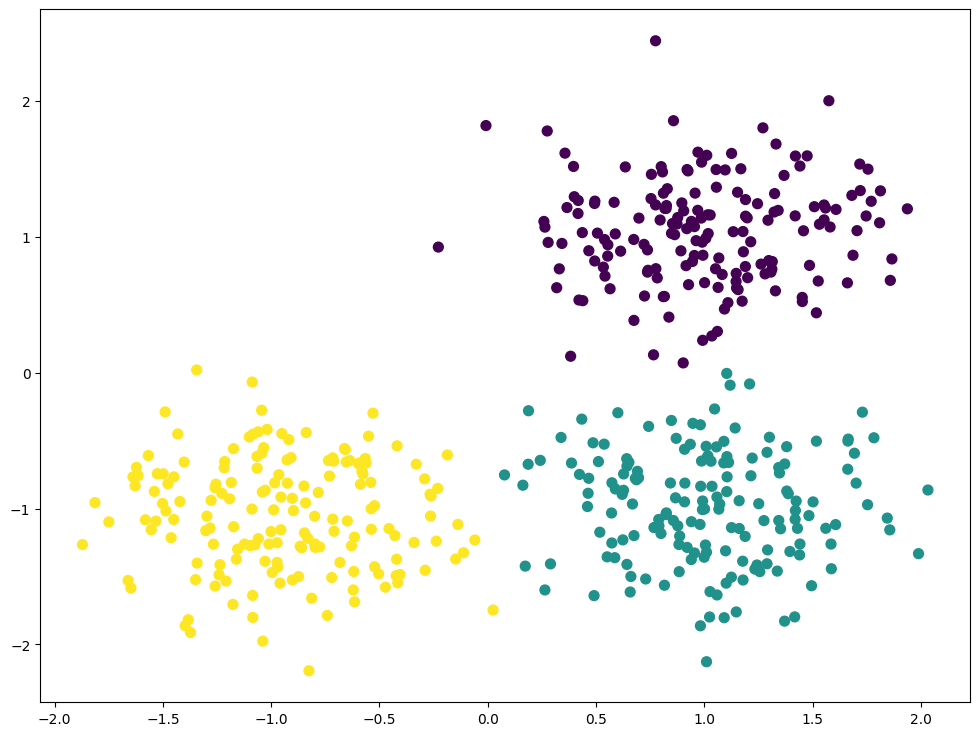

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], c=predicted, s=50)
plt.show()

Ситуация ровно аналогичная.  
Для иллюстрации разницы между этими алгоритмами рассмотрим следующую ситуацию.

In [ ]:
predicted = KMeans(n_clusters=3, init='random', n_init=1, max_iter=1).fit_predict(X)

predicted

array([0, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 1, 0, 0, 2,
       1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 1, 0, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 1, 2, 0, 1, 0, 1, 1, 1, 1, 2, 2,
       1, 1, 2, 1, 1, 1, 1, 0, 2, 2, 1, 2, 0, 1, 0, 0, 1, 1, 2, 1, 1, 2,
       1, 0, 0, 2, 0, 2, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 0, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 1, 2, 1, 0, 0, 0, 2, 2, 2, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 0, 1, 2, 1, 2, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 2, 2, 0, 1, 1, 1, 0, 0, 1, 2, 2, 0, 2,
       1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 2, 0,
       1, 0, 1, 1, 0, 0, 1, 2, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 2, 1, 2, 0, 2, 1, 1, 1, 1, 2, 2, 0,
       2, 1, 2, 0, 1, 1, 0, 1, 2, 1, 1, 2, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 2, 2, 2, 1, 0, 1, 2, 0, 2, 1, 1, 2, 0, 2, 1, 2, 1, 0, 1, 1,
       2, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0,

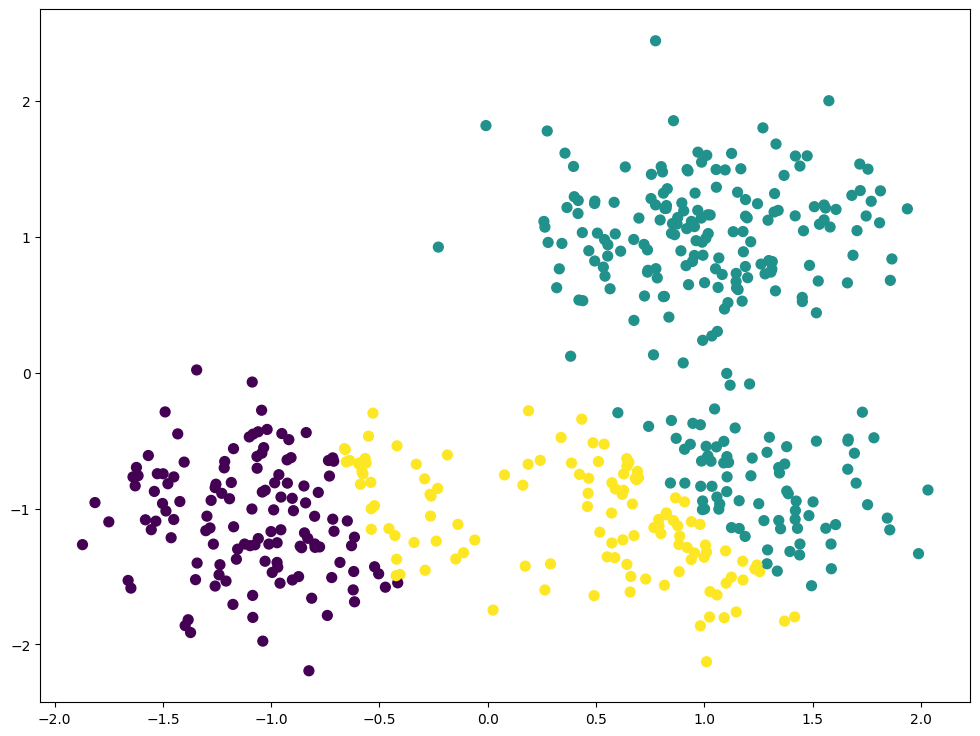

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], c=predicted, s=50)
plt.show()

In [ ]:
predicted = KMeans(n_clusters=3, init='k-means++', n_init=1, max_iter=1).fit_predict(X)

predicted

array([1, 2, 2, 2, 0, 1, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2,
       2, 1, 0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 0, 2, 2, 1, 2, 0, 2,
       0, 0, 0, 1, 1, 1, 0, 2, 2, 2, 0, 0, 1, 1, 0, 1, 2, 0, 2, 0, 2, 2,
       0, 0, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 1, 0, 1, 1, 0, 0, 2, 0, 0, 2,
       0, 1, 1, 2, 1, 1, 0, 0, 2, 2, 1, 2, 0, 2, 1, 0, 0, 0, 1, 0, 2, 2,
       0, 2, 2, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 1, 2, 1, 0, 0,
       2, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 0, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 1, 0, 1, 2, 1, 1,
       0, 1, 1, 2, 2, 1, 0, 1, 1, 2, 0, 1, 1, 0, 1, 0, 1, 2, 1, 0, 1, 1,
       2, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 2, 2, 2, 0, 0, 0, 1,
       0, 2, 1, 2, 0, 1, 1, 2, 2, 2, 2, 0, 1, 1, 2, 0, 2, 2, 0, 2, 1, 1,
       2, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 2, 2, 1, 1, 2, 1, 1, 0, 0, 1, 0,
       2, 0, 2, 2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 2, 1, 1, 0, 1, 0, 1, 2, 0,
       1, 0, 2, 2, 0, 2, 1, 2, 0, 0, 1, 1, 1, 1, 1,

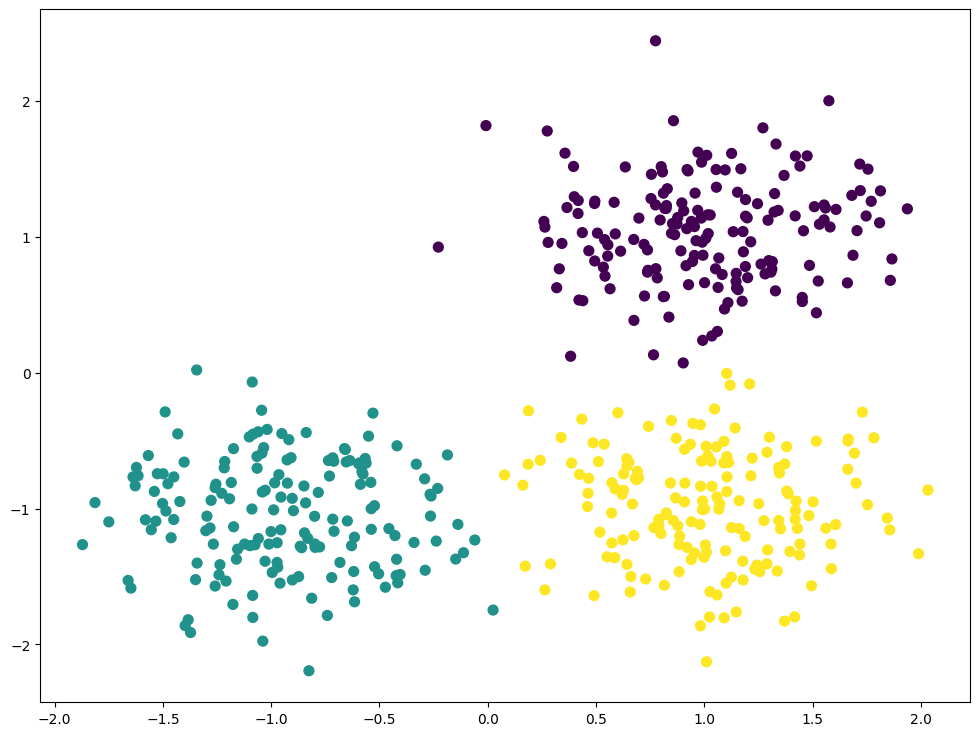

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], c=predicted, s=50)
plt.show()

Эти алгоритмы похожи, но их основная разница - в их старте и что именно выбирается в качестве центроида кластера.  